In [2]:
import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['legend.frameon'] = False
mpl.rcParams['savefig.bbox'] = 'tight'

import jaxsp as jsp

from scipy import constants as const

import matplotlib.animation as animation
from IPython.display import HTML

import Stellar_sim_funcs as SSF
import importlib
importlib.reload(SSF)


from scipy.interpolate import interp1d

from collections import defaultdict

from jaxsp.constants import h, om, hbar, Msun, GN, c, m22

from collections import defaultdict


In [3]:
m22 = 1
u = jsp.set_schroedinger_units(m22)

G = GN.value * (u.from_cm**3) / (u.from_g * u.from_s**2)

In [4]:
rho = jax.vmap(jsp.rho, in_axes=(0,None))

# rho is a function we can input array r and parameter values to get the density

In [5]:
cNFWtides_params = jnp.array([
    357964808.148399 * u.from_Msun, 
    25.690207, 
    0.407461, 
    0.012670 * u.from_Kpc, 
    1.857991 * u.from_Kpc, 
    3.729259
])
density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)
r99 = jsp.enclosing_radius(0.99, density_params) # radius that encloses 99% of mass
print(r99, "kpc")
density_params

20.743367613524313 kpc


core_NFW_tides_params:
	name=236146193804778771,
	M200=1118.7951678146808,
	c=25.690207,
	n=0.407461,
	rc=0.0005960840778498662,
	rt=0.0874126954923718,
	delta=3.729259,
    Derived:
	rs=0.026822448297135815,
	g=0.4307070628318999,
	rho0=1987135.4034031027,

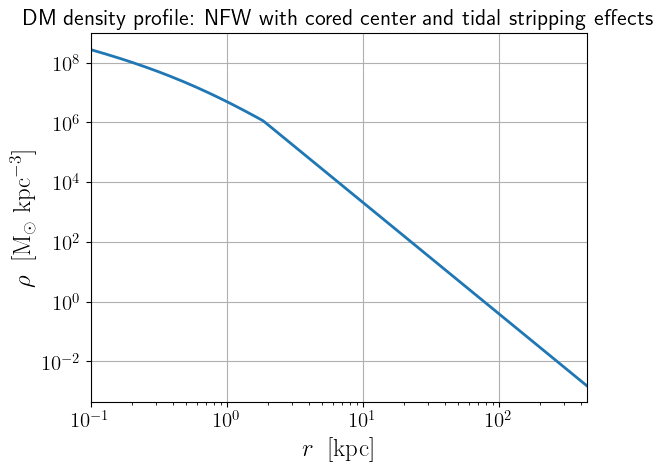

In [6]:
fig, ax = plt.subplots()
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.set_xscale("log")
ax.set_yscale("log")
r = jnp.logspace(jnp.log10(100 * u.from_pc), jnp.log10(r99), 200)
ax.plot(r * u.to_Kpc, rho(r, density_params) * u.to_Msun/u.to_Kpc**3)
ax.set_ylabel(r"$\rho \;\;\mathrm{[M_\odot\;kpc^{-3}]}$", fontsize = 18)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 18)
ax.set_title('DM density profile: NFW with cored center and tidal stripping effects', fontsize = 16)
plt.show()


In [7]:
potential = jax.vmap(jsp.potential, in_axes=(0,None))

In [8]:
rmin = .1 * u.from_pc
rmax = jsp.enclosing_radius(0.999, density_params)
N = 512
potential_params = jsp.init_potential_params(density_params, rmin, rmax, N) 
potential_params

potential_params:
	name=354410778964585829,
	density_params=236146193804778771,
	N=512,
	rmin=4.704688854379371e-06,
	rmax=488.53262239439164,

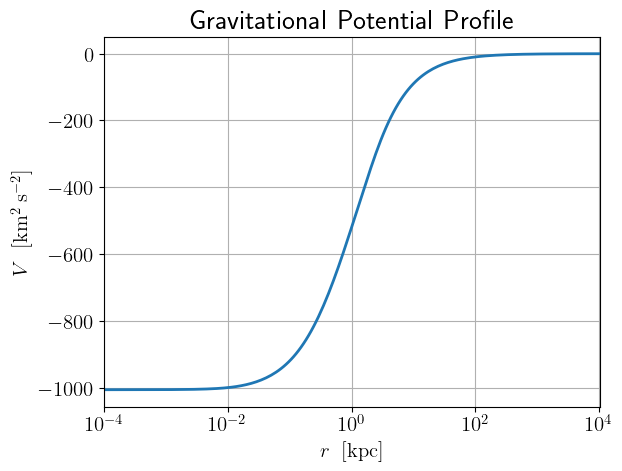

In [9]:
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), 200)
ax.plot(r * u.to_Kpc, potential(r, potential_params) * u.to_kms**2)
ax.set_ylabel(r"$V \;\;\mathrm{[km^2 \;s^{-2}]}$", fontsize = 15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)

ax.set_title('Gravitational Potential Profile', fontsize = 20)
plt.show()

In [10]:
eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0,None))

In [11]:
rmin = .1 * u.from_pc
rmax = jsp.enclosing_radius(0.99, density_params)
print(rmax * u.to_Kpc)
N = 1024
a = 1
b = 10
eigenstate_lib = jsp.init_eigenstate_library(potential_params, rmin, rmax, a, b, N)
eigenstate_lib
n = eigenstate_lib.radial_eigenmode_params.n 
l = eigenstate_lib.radial_eigenmode_params.l
# print(l)
# print(len(n))

440.90838428593


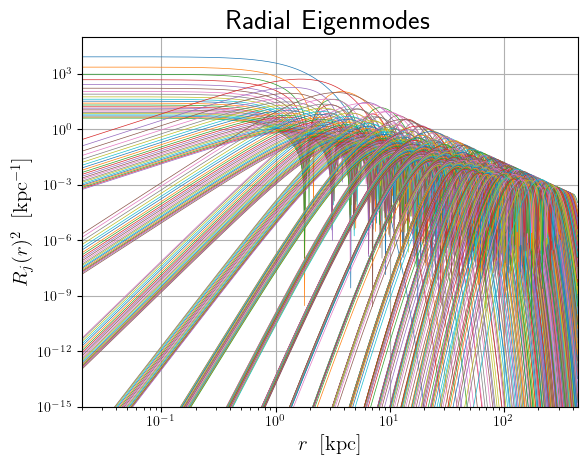

In [12]:
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
r = jnp.logspace(jnp.log10(20 * u.from_pc), jnp.log10(rmax), 1000)
R_j_r = eval_library(r, eigenstate_lib.radial_eigenmode_params)
ax.set_title('Radial Eigenmodes', fontsize = 20)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
ax.set_ylabel(r"$R_{j}(r)^2 \;\;\mathrm{[kpc^{-1}]}$", fontsize = 15)
ax.plot(r * u.to_Kpc, R_j_r**2, lw=0.5)
ax.set_ylim([1e-15, 1e5])
plt.show()

In [13]:
rho_psi = jax.vmap(jsp.rho_psi, in_axes=(0,None,None))

In [14]:
tol = 1e-7
rmin = 20 * u.from_pc
rmax = jsp.enclosing_radius(0.99, density_params)
wavefunction_params = jsp.init_wavefunction_params(eigenstate_lib, density_params, rmin, rmax, tol)
wavefunction_params

wavefunction_params:
	name=321443324063497960,
	eigenstate_library=720428951175803208,
	density_params=236146193804778771,
	aj_2=[3.720980066807119e-29, 0.6378987955514653],
	total_mass=716.415885628137,
	r_min=0.000940937770875874,
	r_max=20.743367613524313,
	distance=0.03034410943743295,

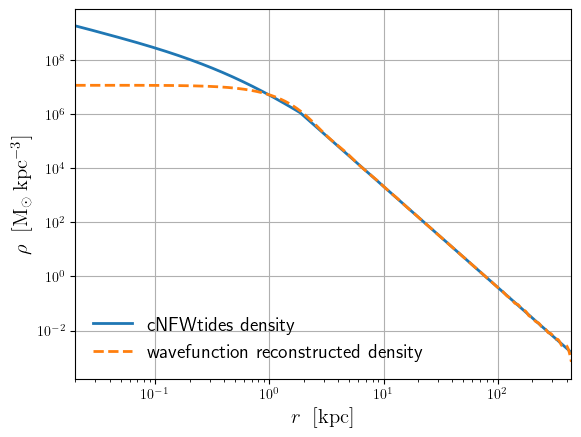

In [15]:
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")

r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), 1000)
ax.plot(r * u.to_Kpc, rho(r, density_params) * u.to_Msun / u.to_Kpc**3, label='cNFWtides density')
ax.plot(r * u.to_Kpc, rho_psi(r, wavefunction_params, eigenstate_lib) * u.to_Msun / u.to_Kpc**3, label='wavefunction reconstructed density', ls='--')
ax.set_ylabel(r"$\rho \;\;\mathrm{[M_\odot\;kpc^{-3}]}$", fontsize = 15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()

# With Time Evolution

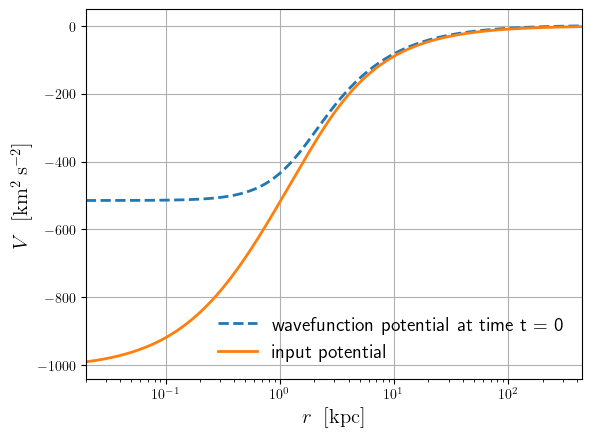

3132.937568921591


In [16]:
r = np.logspace(np.log10(rmin), np.log10(rmax), 1000)

rho_psi_vals = rho_psi(r, wavefunction_params, eigenstate_lib)

Phi_psi = SSF.Obtain_pot(rmin, rmax, rho_psi_vals, r)

fig, ax = plt.subplots()
ax.set_xscale("log")
ax.plot(r * u.to_Kpc, Phi_psi * u.to_kms**2, label='wavefunction potential at time t = 0', lw=2, ls='--')
ax.plot(r * u.to_Kpc, potential(r, potential_params) * u.to_kms**2, label='input potential', lw=2)
ax.set_ylabel(r"$V \;\;\mathrm{[km^2 \;s^{-2}]}$", fontsize = 15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()

m_dm = 1 * 10**(-22) * 1.6 * 10**(-19) / (3 * 10**(8))**2  # mass of dark matter particle in units of 10^-22 eV

h_bar = hbar.value * 1e-7

dt_De_B = h_bar / (m_dm * 6000) * u.from_s # in seconds

print(dt_De_B * u.to_Gyr)

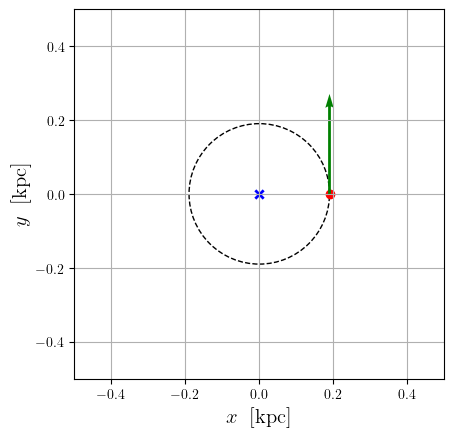

In [17]:
r_orbit = 0.19 * u.from_Kpc

init_pos = np.array([r_orbit, 0, 0]) #Starting as position (r_vir, 0, 0) = (x, y, z)

#at r_orbit, need to find value of the force from the wavefunction potential

acc_mag = SSF.Find_acc_mag_from_Phi(r, Phi_psi, r_orbit)

init_vel = np.sqrt(acc_mag * r_orbit) * np.array([0, 1, 0]) #Circular orbit velocity (vx, vy, vz)

init_pos_sph = SSF.Cartesian_to_sph(init_pos[0], init_pos[1], init_pos[2])
init_vel_sph = SSF.Cartesian_to_sph_vel(init_pos[0], init_pos[1], init_pos[2], init_vel[0], init_vel[1], init_vel[2])

orbit = plt.Circle((0, 0), r_orbit * u.to_Kpc, color='black', fill=False, linestyle='--', label='Star Orbit')
fig, ax = plt.subplots() 

ax.add_patch(orbit)
ax.set_xlim(-0.5 , 0.5)
ax.set_ylim(-0.5 , 0.5)

ax.set_aspect('equal', adjustable='box')

plt.scatter(r_orbit * u.to_Kpc, 0, color='red', label='Star Initial Position')
plt.scatter(0, 0, color='blue', label='Halo Center', marker='x')
plt.quiver(r_orbit * u.to_Kpc, 0, 0, init_vel[1] * u.to_kms, label='Star Initial Velocity', angles='xy', scale_units='xy', scale=10, color='green')

ax.set_xlabel(r"$x \;\;\mathrm{[kpc]}$", fontsize = 15)
ax.set_ylabel(r"$y \;\;\mathrm{[kpc]}$", fontsize = 15)
plt.show()


(1000, 290)


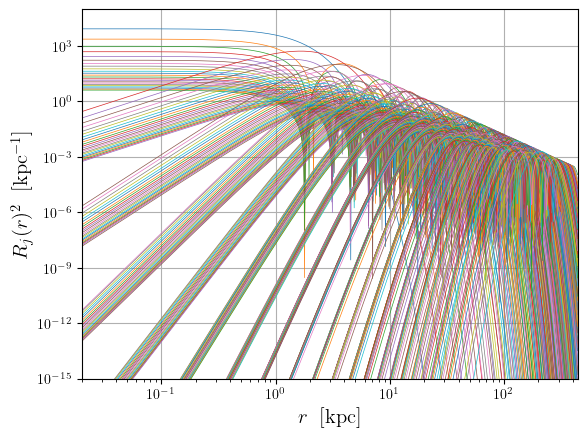

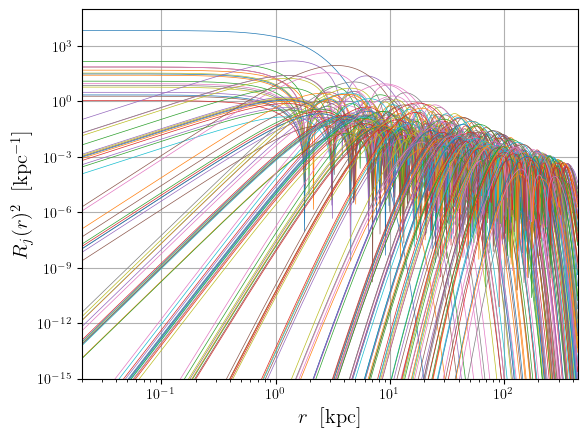

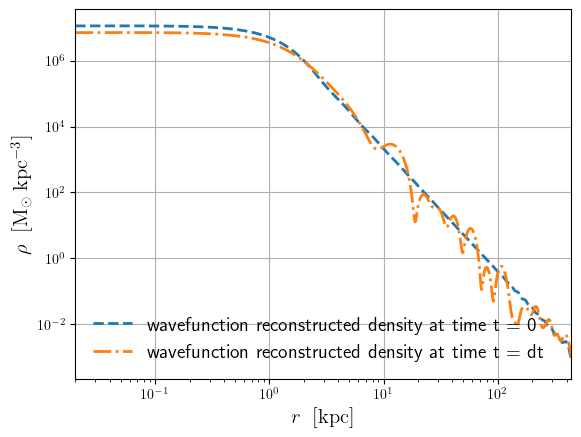

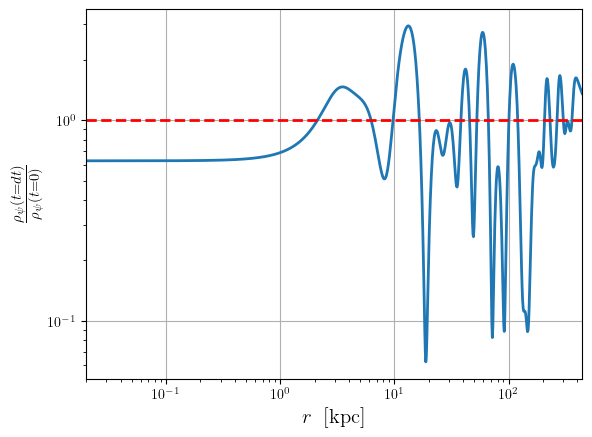

In [24]:
importlib.reload(SSF)


total_evolve_time = 5 * u.from_Gyr
num_steps = 10000
dt = total_evolve_time / num_steps

rho_rtp, rho_psi_time_stepped, radial_eigen_functions, radial_eigen_function_time_stepped, theta, phi, dtheta, dphi = SSF.Calculating_rho_from_psi_3d(r, eigenstate_lib, wavefunction_params, dt, eval_library)

plt.plot(r * u.to_Kpc, radial_eigen_functions**2, lw=0.5)
plt.xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize=15)
plt.ylabel(r"$R_{j}(r)^2 \;\;\mathrm{[kpc^{-1}]}$", fontsize=15)
plt.xscale("log")
plt.yscale("log")
plt.ylim([1e-15, 1e5])
plt.xlim([rmin * u.to_Kpc, rmax * u.to_Kpc])
plt.show()

plt.plot(r * u.to_Kpc, radial_eigen_function_time_stepped**2, lw=0.5)
plt.xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize=15)
plt.ylabel(r"$R_{j}(r)^2 \;\;\mathrm{[kpc^{-1}]}$", fontsize=15)
plt.xscale("log")
plt.yscale("log")
plt.ylim([1e-15, 1e5])
plt.show()


fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")

rho0 = rho_psi(r, wavefunction_params, eigenstate_lib)

ax.plot(r * u.to_Kpc,rho0 * u.to_Msun / u.to_Kpc**3,label='wavefunction reconstructed density at time t = 0',ls='--')
ax.plot(r * u.to_Kpc,rho_psi_time_stepped * u.to_Msun / u.to_Kpc**3,label='wavefunction reconstructed density at time t = dt',ls='-.')
ax.set_ylabel(r"$\rho \;\;\mathrm{[M_\odot\;kpc^{-3}]}$", fontsize=15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize=15)
plt.legend(fontsize=14)
plt.show()

fraction = rho_psi_time_stepped / rho0
plt.plot(r * u.to_Kpc, fraction)
plt.xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize=15)
plt.ylabel(r"$\frac{\rho_{\psi}(t=dt)}{\rho_{\psi}(t=0)}$", fontsize=15)
plt.axhline(1, color='red', ls='--')
plt.xscale("log")
plt.yscale("log")
plt.show()


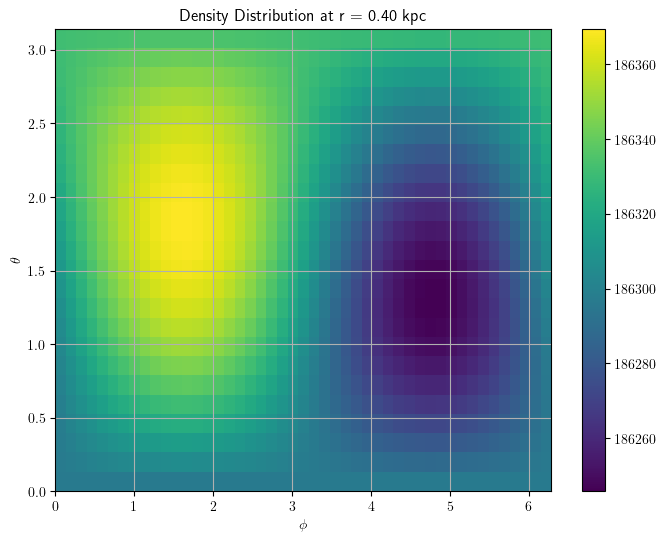

In [25]:
plt.figure(figsize=(8, 6))
i = 300
plt.imshow(rho_rtp[i,:,:], extent=(0, 2 * np.pi, 0, np.pi), aspect='auto')
plt.colorbar()
plt.xlabel(r'$\phi$')
plt.ylabel(r'$\theta$')
plt.title('Density Distribution at r = %.2f kpc' % (r[i] * u.to_Kpc))
plt.show()



In [26]:

importlib.reload(SSF)
Phi_rtp, Phi_r_dt, phi_lm = SSF.Calculating_Phi_from_rho_in_3d(l, rho_rtp, r, dtheta, dphi, theta, phi)


(l, m) = (0, 0)
(l, m) = (1, -1)
(l, m) = (1, 0)
(l, m) = (1, 1)
(l, m) = (2, -2)
(l, m) = (2, -1)
(l, m) = (2, 0)
(l, m) = (2, 1)
(l, m) = (2, 2)
(l, m) = (3, -3)
(l, m) = (3, -2)
(l, m) = (3, -1)
(l, m) = (3, 0)
(l, m) = (3, 1)
(l, m) = (3, 2)
(l, m) = (3, 3)
(l, m) = (4, -4)
(l, m) = (4, -3)
(l, m) = (4, -2)
(l, m) = (4, -1)
(l, m) = (4, 0)
(l, m) = (4, 1)
(l, m) = (4, 2)
(l, m) = (4, 3)
(l, m) = (4, 4)
(l, m) = (5, -5)
(l, m) = (5, -4)
(l, m) = (5, -3)
(l, m) = (5, -2)
(l, m) = (5, -1)
(l, m) = (5, 0)
(l, m) = (5, 1)
(l, m) = (5, 2)
(l, m) = (5, 3)
(l, m) = (5, 4)
(l, m) = (5, 5)
(l, m) = (6, -6)
(l, m) = (6, -5)
(l, m) = (6, -4)
(l, m) = (6, -3)
(l, m) = (6, -2)
(l, m) = (6, -1)
(l, m) = (6, 0)
(l, m) = (6, 1)
(l, m) = (6, 2)
(l, m) = (6, 3)
(l, m) = (6, 4)
(l, m) = (6, 5)
(l, m) = (6, 6)
(l, m) = (7, -7)
(l, m) = (7, -6)
(l, m) = (7, -5)
(l, m) = (7, -4)
(l, m) = (7, -3)
(l, m) = (7, -2)
(l, m) = (7, -1)
(l, m) = (7, 0)
(l, m) = (7, 1)
(l, m) = (7, 2)
(l, m) = (7, 3)
(l, m) = (7,

KeyboardInterrupt: 

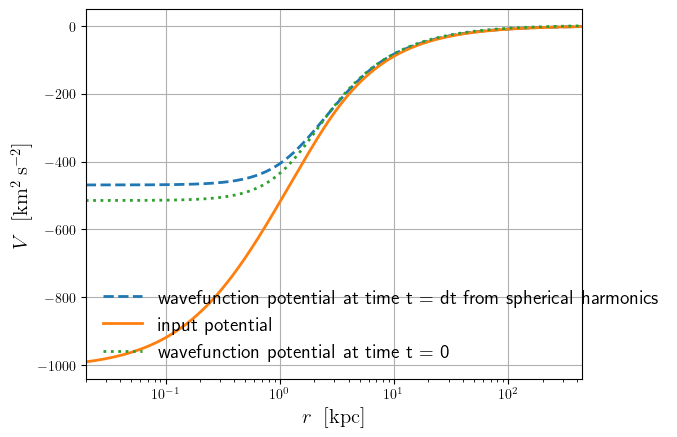

In [ ]:

fig, ax = plt.subplots()
ax.set_xscale("log")
ax.plot(r * u.to_Kpc, Phi_r_dt * u.to_kms**2, label='wavefunction potential at time t = dt from spherical harmonics', lw=2, ls='--')
ax.plot(r * u.to_Kpc, potential(r, potential_params) * u.to_kms**2, label='input potential', lw=2)
ax.plot(r * u.to_Kpc, Phi_psi * u.to_kms**2, label='wavefunction potential at time t = 0', lw=2, ls=':')
ax.set_ylabel(r"$V \;\;\mathrm{[km^2 \;s^{-2}]}$", fontsize = 15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()



## $\vec{a} = -\vec{\nabla} V$
## $\vec{a} = -(\frac{dV}{dr}\vec{\hat{r}} + \frac{1}{r}\frac{dV}{d\theta}\vec{\hat{\theta}} + \frac{1}{r\sin{\theta}}\frac{dV}{d\phi}\vec{\hat{\phi}})$

In [ ]:
import numpy as np

print(Phi_rtp.shape)

def calculate_acceleration_spherical(Phi_rtp, r, theta, phi):
    """
    Calculate acceleration vector a = -grad(V) in spherical coordinates.
    
    Parameters:
    -----------
    Phi_rtp : ndarray, shape (nr, ntheta, nphi)
        Scalar field values at each grid point
    r : ndarray, shape (nr,)
        Radial coordinate values
    theta : ndarray, shape (ntheta,)
        Polar angle values (0 to pi)
    phi : ndarray, shape (nphi,)
        Azimuthal angle values (0 to 2pi)
    
    Returns:
    --------
    a_r, a_theta, a_phi : ndarrays, each shape (nr, ntheta, nphi)
        Components of acceleration vector in spherical coordinates
    """
    # Compute derivatives using numpy gradient
    # gradient returns derivatives in the order of array dimensions
    dV_dr, dV_dtheta, dV_dphi = np.gradient(Phi_rtp, r, theta, phi)

    print(dV_dr.shape, dV_dtheta.shape, dV_dphi.shape)
    
    # Create 3D meshgrid for r and theta (needed for metric factors)
    R, THETA, PHI = np.meshgrid(r, theta, phi, indexing='ij')
    
    # Apply metric factors for spherical coordinates
    grad_V_r = dV_dr
    grad_V_theta = (1 / R) * dV_dtheta
    grad_V_phi = (1 / (R * np.sin(THETA))) * dV_dphi
    
    # Acceleration is negative gradient
    a_r = -grad_V_r
    a_theta = -grad_V_theta
    a_phi = -grad_V_phi
    
    return a_r, a_theta, a_phi

# Example usage:
a_r, a_theta, a_phi = calculate_acceleration_spherical(Phi_rtp, r, theta, phi)


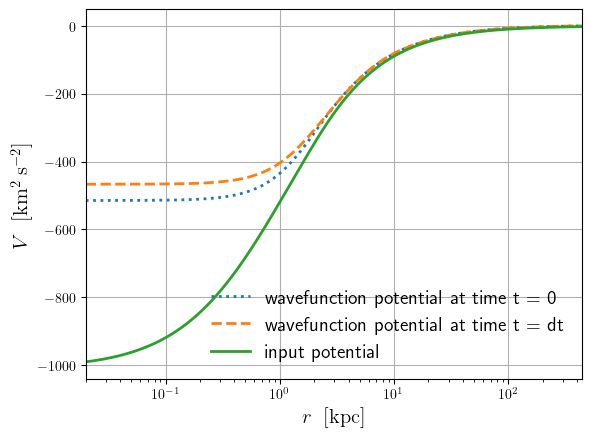

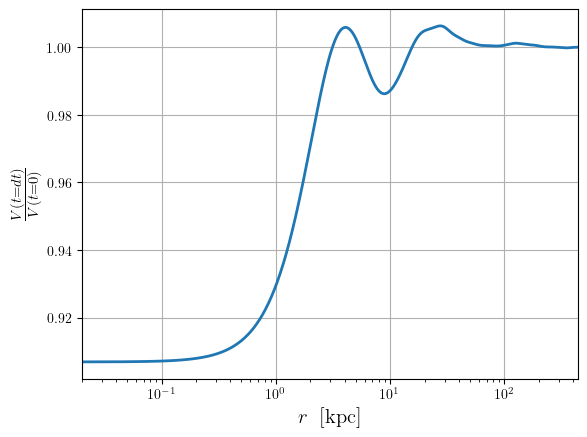

In [ ]:

Phi_psi_dt = SSF.Obtain_pot(rmin, rmax, rho_psi_time_stepped, r)

fig, ax = plt.subplots()
ax.set_xscale("log")


ax.plot(r * u.to_Kpc,  Phi_psi * u.to_kms**2, label='wavefunction potential at time t = 0', lw=2, ls=':')
ax.plot(r * u.to_Kpc, Phi_psi_dt * u.to_kms**2, label='wavefunction potential at time t = dt', lw=2, ls='--')
ax.plot(r * u.to_Kpc, potential(r, potential_params) * u.to_kms**2, label='input potential', lw=2)
ax.set_ylabel(r"$V \;\;\mathrm{[km^2 \;s^{-2}]}$", fontsize = 15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()


plt.plot(r * u.to_Kpc, Phi_psi_dt/Phi_psi)
plt.xscale('log')
plt.xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize=15)
plt.ylabel(r"$\frac{V(t=dt)}{V(t=0)}$", fontsize=15)
plt.show()

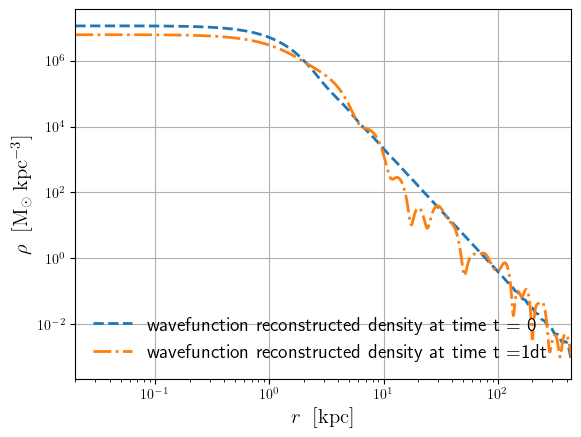

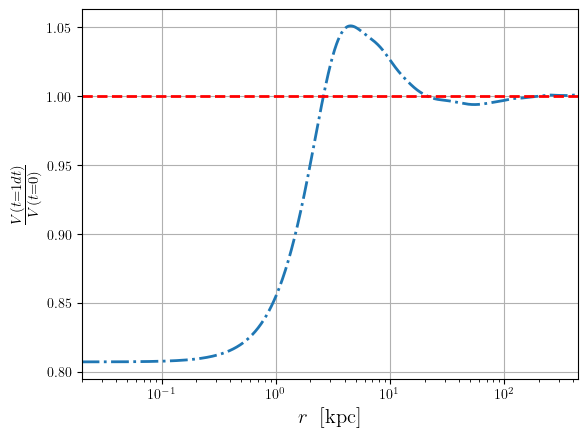

542.0550022373031


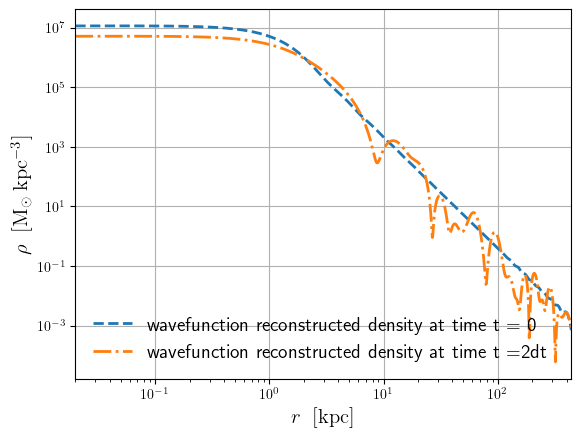

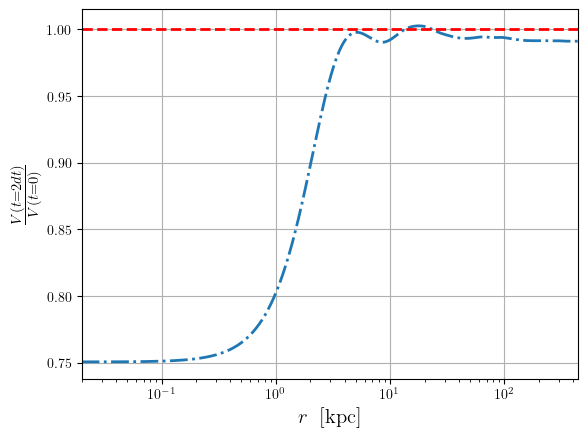

453.51306998318677


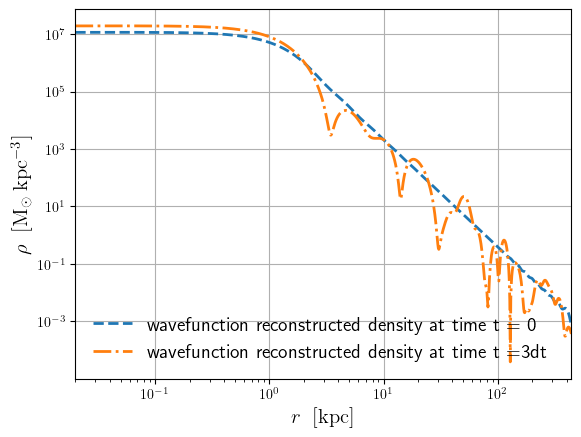

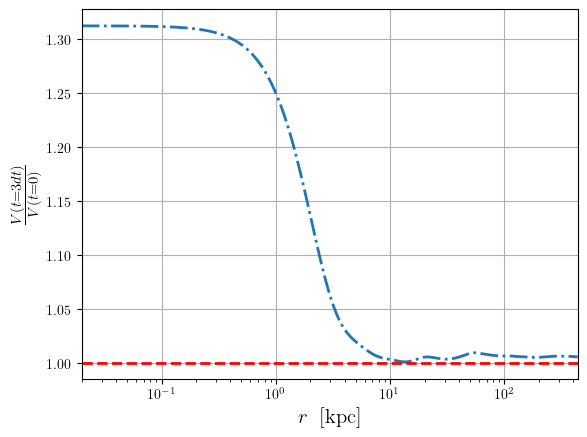

1682.7741276856877


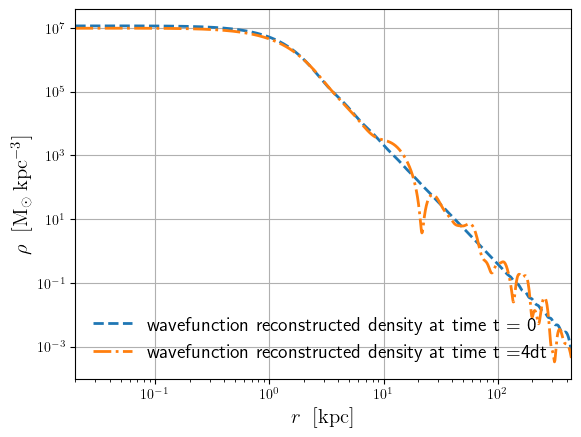

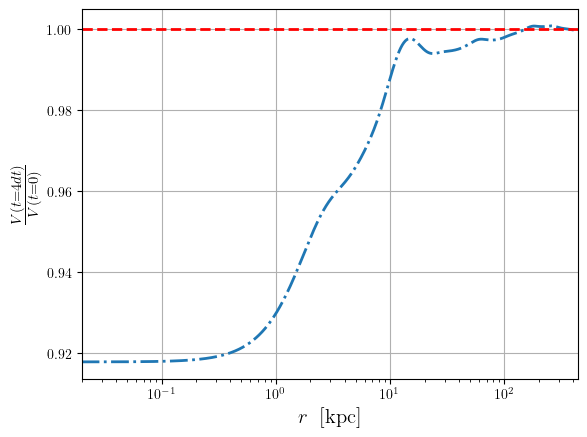

850.7420353570543


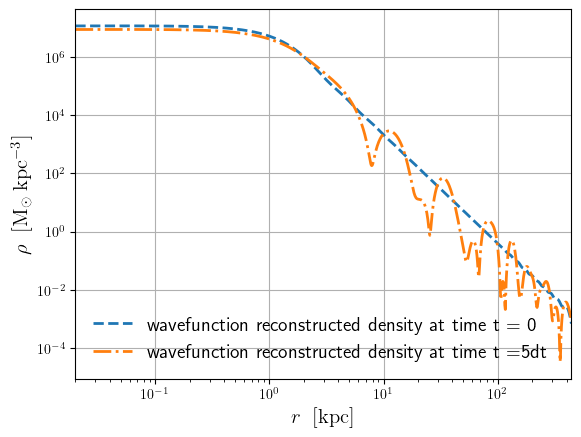

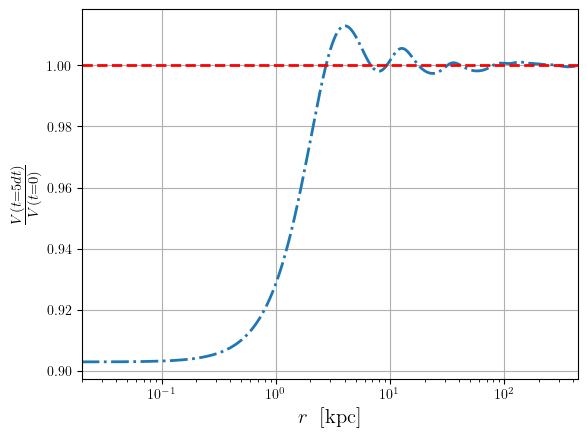

758.6398083276449
[-0.10414345 -0.07308614  0.        ]


In [ ]:

dt = 60 * u.from_Myr
num_steps = 5

r_lin = np.linspace(rmin, rmax, 1000)
r_orbit = 0.19 * u.from_Kpc

acc_mag = SSF.Find_acc_mag_from_Phi(r, Phi_psi, r_orbit)

init_vel = np.sqrt(acc_mag * r_orbit) * np.array([0, 1, 0]) #Circular orbit velocity

eigen_energies = eigenstate_lib.radial_eigenmode_params.E
l = eigenstate_lib.radial_eigenmode_params.l

aj_2 = wavefunction_params.aj_2
theta = jax.random.uniform(jax.random.PRNGKey(0), shape=aj_2.shape, minval=0.0, maxval=2*jnp.pi)
aj = jnp.sqrt(aj_2)


total_mass = wavefunction_params.total_mass

R_j_r = eval_library(r, eigenstate_lib.radial_eigenmode_params)

radial_eigen_functions = R_j_r


r_pos = init_pos
v = init_vel


for i in range(num_steps):
    r_dt, v_dt, rho_psi_time_stepped = SSF.Time_step_t_dep(r_pos, v, dt, acc_mag, r, eigen_energies, l, radial_eigen_functions, aj, total_mass, k = i + 1)
    r_pos = r_dt
    v = v_dt
    
    fig, ax = plt.subplots()
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.plot(r * u.to_Kpc, rho_psi(r, wavefunction_params, eigenstate_lib) * u.to_Msun / u.to_Kpc**3, label='wavefunction reconstructed density at time t = 0', ls='--')
    ax.plot(r * u.to_Kpc, rho_psi_time_stepped * u.to_Msun / u.to_Kpc**3, label='wavefunction reconstructed density at time t =' + str(i+1) + 'dt', ls='-.')
    ax.set_ylabel(r"$\rho \;\;\mathrm{[M_\odot\;kpc^{-3}]}$", fontsize = 15)
    ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
    plt.legend(fontsize = 14)
    plt.show()

    Phi_psi_dt = SSF.Obtain_pot(rmin, rmax, rho_psi_time_stepped, r)

    fig, ax = plt.subplots()
    ax.set_xscale("log")
    ax.plot(r * u.to_Kpc,  Phi_psi_dt / Phi_psi, lw=2, ls='-.')
    ax.set_ylabel(r"$\frac{V(t="+ str(i+1) + "dt)}{V(t=0)}$", fontsize = 15)
    ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
    plt.legend(fontsize = 14)
    plt.axhline(1, color='red', ls='--')
    plt.show()

    acc_mag = SSF.Find_acc_mag_from_rho(r, rho_psi_time_stepped, r_orbit)

    print(acc_mag)


final_r = r_pos

print(final_r* u.to_Kpc)



1005.7497168224885


KeyboardInterrupt: 

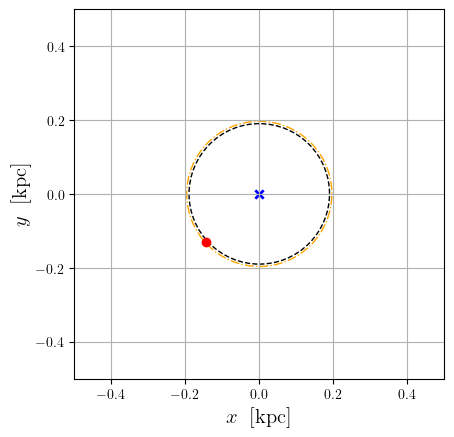

In [ ]:

total_evolve_time = 10 * u.from_Gyr
num_steps = 1000
dt = total_evolve_time / num_steps

r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), 1000)

r_orbit = 0.19 * u.from_Kpc
init_pos = np.array([r_orbit, 0, 0]) #Starting as position (r_vir, 0, 0) = (x, y, z)

acc_mag = SSF.Find_acc_mag_from_Phi(r, Phi_psi, r_orbit)

print(acc_mag)

init_vel = np.sqrt(acc_mag * r_orbit) * np.array([0, 1, 0]) #Circular orbit velocity

ani = SSF.Make_animation_t_dep(r_orbit, init_pos, init_vel, dt, num_steps, acc_mag, r, eigen_energies, l, radial_eigen_functions, aj, total_mass, rmin, rmax)

HTML(ani.to_jshtml())

In [ ]:
total_evolve_time = 10 * u.from_Gyr
num_steps = 10000
dt = total_evolve_time / num_steps

r_orbit = 0.19 * u.from_Kpc
init_pos = np.array([r_orbit, 0, 0]) #Starting as position (r_vir, 0, 0) = (x, y, z)

total_mag_r, total_avg_r, stellar_v_disp = SSF.Simulate_time_dep(r_orbit, init_pos, dt, num_steps, r, eigen_energies, l, radial_eigen_functions, aj, total_mass, rmin, rmax, Phi_psi)



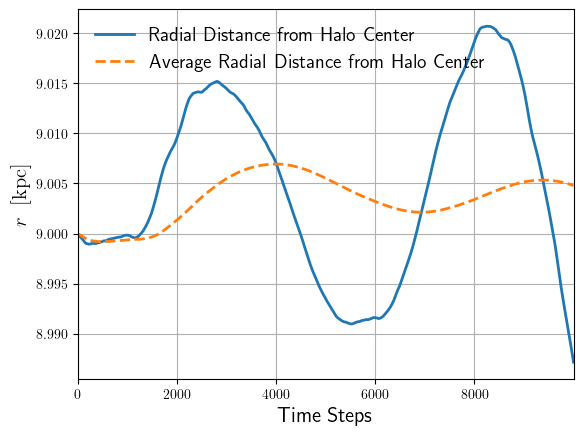

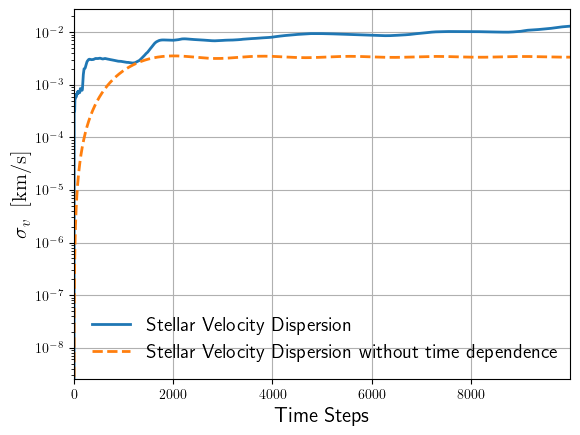

In [ ]:
fig, ax = plt.subplots()

total_mag_r = jnp.array(total_mag_r)
total_avg_r = jnp.array(total_avg_r)


ax.plot(np.arange(num_steps), jnp.array(total_mag_r) * u.to_Kpc, label='Radial Distance from Halo Center')
ax.plot(np.arange(num_steps), jnp.array(total_avg_r) * u.to_Kpc, label='Average Radial Distance from Halo Center', ls='--')
ax.set_ylabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
ax.set_xlabel(r"Time Steps", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()

fig, ax = plt.subplots()

stellar_v_disp = jnp.array(stellar_v_disp)
stellar_vel_disp_no_t = jnp.array(stellar_vel_disp_no_t)

ax.plot(np.arange(num_steps), stellar_v_disp * u.to_kms, label='Stellar Velocity Dispersion')
ax.plot(np.arange(num_steps), stellar_vel_disp_no_t * u.to_kms, label='Stellar Velocity Dispersion without time dependence', ls='--')
plt.yscale('log')
ax.set_ylabel(r"$\sigma_v \;\;\mathrm{[km/s]}$", fontsize = 15)
ax.set_xlabel(r"Time Steps", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()

In [ ]:
m_dm = 1 * 10**(-22) * 1.6 * 10**(-19) / (3 * 10**(8))**2  # mass of dark matter particle in units of 10^-22 eV

h_bar = hbar.value * 1e-7

t = [i * dt for i in range(num_steps)] # time

t = np.array(t) * u.to_s

dm_v_disp = 6000 # m/s from paper

stellar_v_disp_plot = np.array(stellar_v_disp) * u.to_cm / (u.to_s * 100)

r_half = (9 * (h_bar / m_dm)**3 * t * (stellar_v_disp_plot**2)/(dm_v_disp**4))**(1/4)

m_to_pc = 3.24078 * 10**(-19)
s_to_Gyr = 3.16888 * 10**(-17)

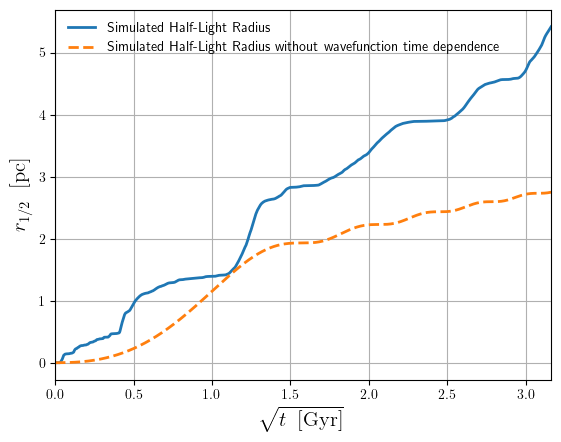

In [ ]:

fig, ax = plt.subplots()

t_no_t = t


plt.plot(np.sqrt(t * s_to_Gyr) , r_half * m_to_pc, label='Simulated Half-Light Radius')
plt.plot(np.sqrt(t_no_t * s_to_Gyr), r_half_no_t * m_to_pc, label='Simulated Half-Light Radius without wavefunction time dependence', ls='--')

plt.xlabel(r"$\sqrt{t \;\;\mathrm{[Gyr]}}$", fontsize = 15)
plt.ylabel(r"$r_{1/2} \;\;\mathrm{[pc]}$", fontsize = 15)
plt.legend(fontsize = 10)

plt.show()

In [ ]:
from sympy.physics.wigner import wigner_3j
import numpy as np
import jax.numpy as jnp

def C_coeff(l1,m1,l2,m2,L,M):
    return ((-1)**m2
            * np.sqrt((2*l1+1)*(2*l2+1)*(2*L+1)/(4*np.pi))
            * wigner_3j(l1,l2,L,0,0,0)
            * wigner_3j(l1,l2,L,m1,-m2,M))


In [ ]:
# for multiplying Y11 with Y10

l1 = 1
m1 = 1
l2 = 0
m2 = 0

coeffs = [C_coeff(l1, m1, l2, m2, 0, 0), C_coeff(l1, m1, l2, m2, 1, -1), C_coeff(l1, m1, l2, m2, 1, 0), C_coeff(l1, m1, l2, m2, 1, 1), C_coeff(l1, m1, l2, m2, 2, -2), C_coeff(l1, m1, l2, m2, 2, -1), C_coeff(l1, m1, l2, m2, 2, 0), C_coeff(l1, m1, l2, m2, 2, 1), C_coeff(l1, m1, l2, m2, 2, 2)]

print(coeffs)


[0, -0.282094791773878, 0, 0, 0, 0, 0, 0, 0]
